# HET Quick-Look Evidence & Presentation Playground

This notebook is intentionally **not another reduction pipeline**. It is a place to:

1. discover and inspect real VIRUS/LRS2 observations;
2. run the already-established quick-look workflows;
3. inspect the evidence carried by each result;
4. iterate rapidly on plots and presentation choices.

Current scientific defaults encoded by the package:

| Setting | VIRUS | LRS2 |
|---|---:|---:|
| Fractional extraction width | 5 detector pixels | 5 detector pixels |
| Collapse window | central 200 columns | central 200 columns |
| Collapse statistic | median | median |
| Gaussian splat FWHM | 1.5 arcsec | 1.2 arcsec |
| Pixel scale | 1.0 arcsec/pixel | 0.4 arcsec/pixel |
| Standard-star fiducial | (0, 0) in selected IFU | (0, 0) in LRS2 IFU |

The guiding philosophy is **evidence supply**: show the observer the data, topology, support, and pointing information clearly. Do not turn these plots into automated pass/fail decisions.

## 1. Session configuration

Edit only this cell for the dataset you want to explore.

The documented local examples use separate VIRUS and LRS2 roots, so the notebook keeps one root per instrument. `TRACE_ROOT` should be the directory that contains `Fiber_Locations/`.

In [1]:
from pathlib import Path
import sys

INSTRUMENT = "lrs2"           # "lrs2" or "virus"
DATES = {"lrs2": "20260512", "virus": "20260609"}
DATE = DATES[INSTRUMENT]

RAW_ROOTS = {
    "lrs2": Path("~/data/LRS2").expanduser(),
    "virus": Path("~/data/VIRUS").expanduser(),
}

# Find the checkout whether Jupyter was started in the repository or in notebooks/.
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src" / "hetquicklook").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src" / "hetquicklook").is_dir():
    raise FileNotFoundError("Could not locate the HET_LV_Tools checkout")
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Directory containing Fiber_Locations/.
TRACE_ROOT = PROJECT_ROOT

RAW_ROOT = RAW_ROOTS[INSTRUMENT]

print("instrument:", INSTRUMENT)
print("date:", DATE)
print("raw root:", RAW_ROOT)
print("trace root:", TRACE_ROOT)

instrument: lrs2
date: 20260512
raw root: /Users/grz85/data/LRS2
trace root: /Users/grz85/work/code/HET_LV_Tools


## 2. Imports and API inspection

The public quick-look path is still evolving at the workflow-integration boundary. This cell deliberately prints signatures so the notebook remains useful while we refine that API rather than hiding changes behind notebook-specific wrappers.

In [2]:
import inspect
import numpy as np
import matplotlib.pyplot as plt

from hetquicklook import (
    QuicklookConfig,
    discover_observations,
    load_observation,
    lrs2_channel_for,
)
from hetquicklook.fibers import FiberTopology
import hetquicklook.workflows as ql_workflows
import hetquicklook.topology as ql_topology
import hetquicklook.algorithms.detector as ql_detector
import hetquicklook.algorithms.trace as ql_trace
import hetquicklook.algorithms.extraction as ql_extraction
import hetquicklook.algorithms.collapse as ql_collapse
import hetquicklook.algorithms.spatial as ql_spatial

def show_signature(module, name):
    obj = getattr(module, name, None)
    if obj is None:
        print(f"{module.__name__}.{name}: not present")
    else:
        print(f"{module.__name__}.{name}{inspect.signature(obj)}")

for module, name in [
    (ql_workflows, "run_ldls_flat_quicklook"),
    (ql_workflows, "run_standard_star_quicklook"),
    (ql_detector, "reduce_amplifier_array"),
    (ql_trace, "fit_fiber_traces"),
    (ql_extraction, "extract_fractional_aperture"),
]:
    show_signature(module, name)

hetquicklook.workflows.run_ldls_flat_quicklook(detector: 'np.ndarray', topology: 'FiberTopology', *, detector_variance: 'np.ndarray | None' = None, trace_map: 'np.ndarray | None' = None, extraction_width: 'float' = 5.0, collapse_columns: 'int' = 200, statistic: 'str' = 'median', aperture: 'int | float | None' = None, gaussian_fwhm: 'float | None' = None, pixel_scale: 'float | None' = None, instrument: 'Instrument | str' = <Instrument.VIRUS: 'virus'>, spatial_defaults: 'Mapping[str, object] | None' = None, output_shape: 'tuple[int, int] | None' = None, origin: 'tuple[float, float] | None' = None) -> 'SpatialQuicklook'
hetquicklook.workflows.run_standard_star_quicklook(detector: 'np.ndarray', topology: 'FiberTopology', *, requested_position: 'tuple[float, float] | None' = None, detector_variance: 'np.ndarray | None' = None, trace_map: 'np.ndarray | None' = None, extraction_width: 'float' = 5.0, collapse_columns: 'int' = 200, statistic: 'str' = 'median', aperture: 'int | float | None' = N

## 3. Discover a night and inspect observations

Discovery answers **what is present**, not whether an observation is scientifically complete.

In [3]:
config = QuicklookConfig(RAW_ROOT)

discovered = discover_observations(
    config,
    instrument=INSTRUMENT,
    date=DATE,
)

print(f"Discovered {len(discovered)} observation archive(s)")
for i, item in enumerate(discovered):
    print(i, item)

Discovered 37 observation archive(s)
0 DiscoveredObservation(archive_path=PosixPath('/Users/grz85/data/LRS2/20260512/lrs2/lrs20000001.tar'), date=datetime.date(2026, 5, 12), instrument=<Instrument.LRS2: 'lrs2'>, outer_tar_member=None)
1 DiscoveredObservation(archive_path=PosixPath('/Users/grz85/data/LRS2/20260512/lrs2/lrs20000002.tar'), date=datetime.date(2026, 5, 12), instrument=<Instrument.LRS2: 'lrs2'>, outer_tar_member=None)
2 DiscoveredObservation(archive_path=PosixPath('/Users/grz85/data/LRS2/20260512/lrs2/lrs20000003.tar'), date=datetime.date(2026, 5, 12), instrument=<Instrument.LRS2: 'lrs2'>, outer_tar_member=None)
3 DiscoveredObservation(archive_path=PosixPath('/Users/grz85/data/LRS2/20260512/lrs2/lrs20000004.tar'), date=datetime.date(2026, 5, 12), instrument=<Instrument.LRS2: 'lrs2'>, outer_tar_member=None)
4 DiscoveredObservation(archive_path=PosixPath('/Users/grz85/data/LRS2/20260512/lrs2/lrs20000005.tar'), date=datetime.date(2026, 5, 12), instrument=<Instrument.LRS2: 'lrs2

Choose one archive to inspect. Multi-exposure tars remain multi-exposure observations; the package exposes the encoded exposure groups separately.

In [4]:
OBS_INDEX = 0

observation = load_observation(discovered[OBS_INDEX])

print("Observation:")
print(observation)

print("\nExposure IDs:")
for exposure_id in observation.group_by_exposure():
    print(" ", exposure_id)

Observation:
Observation(discovered=DiscoveredObservation(archive_path=PosixPath('/Users/grz85/data/LRS2/20260512/lrs2/lrs20000001.tar'), date=datetime.date(2026, 5, 12), instrument=<Instrument.LRS2: 'lrs2'>, outer_tar_member=None), members=(ArchiveMember(archive_path=PosixPath('/Users/grz85/data/LRS2/20260512/lrs2/lrs20000001.tar'), member_name='lrs20000001/exp01/lrs2/20260512T015436.4_056LL_twi.fits', size=4409280, outer_tar_member=None, identity=RawFrameIdentity(exposure_id='20260512T015436.4', amplifier_token='056LL', frame_type='twi'), parse_error=None), ArchiveMember(archive_path=PosixPath('/Users/grz85/data/LRS2/20260512/lrs2/lrs20000001.tar'), member_name='lrs20000001/exp01/lrs2/20260512T015436.4_056LU_twi.fits', size=4409280, outer_tar_member=None, identity=RawFrameIdentity(exposure_id='20260512T015436.4', amplifier_token='056LU', frame_type='twi'), parse_error=None), ArchiveMember(archive_path=PosixPath('/Users/grz85/data/LRS2/20260512/lrs2/lrs20000001.tar'), member_name='lrs

## 4. Inspect exposure metadata and classification

This is useful before touching detector pixels. For flats, look for the established `ldls_long`, `ldls_long_B`, or `Qth_R` classifications. For standards, the package uses the 45-name HET/Hydra catalog plus explicit historical aliases.

In [5]:
def exposure_evidence(obs):
    rows = []
    for exposure_id in obs.group_by_exposure():
        exposure = obs.exposure_for(exposure_id)
        rows.append({
            "exposure_id": exposure_id,
            "classification": getattr(exposure, "classification", None),
            "metadata": getattr(exposure, "metadata", None),
            "n_frames": len(getattr(exposure, "frames", [])),
        })
    return rows

for row in exposure_evidence(observation):
    print("\nEXPOSURE:", row["exposure_id"])
    print("frames:", row["n_frames"])
    print("classification:", row["classification"])
    print("metadata:", row["metadata"])


EXPOSURE: 20260512T015436.4
frames: 8
classification: ExposureClassification(quicklook_kind=None, calibration_source=None, applicable_ifu_slots=(), standard_target=None, standard_star=None, standard_catalog_available=True, standard_catalog_source='HET/Hydra canonical standard-star table')
metadata: ExposureMetadata(exposure_id='20260512T015436.4', frame_types=('twi',), frame_class='calibration', header_values={'SIMPLE': True, 'BITPIX': 16, 'NAXIS': 2, 'NAXIS1': 2128, 'NAXIS2': 1032, 'EXTEND': True, 'BSCALE': 1, 'BZERO': 32768, 'DATE': '2026-05-12T01:55:39.437072', 'DATE-OBS': '2026-05-12', 'TELESCOP': 'het', 'INSTRUME': 'lrs2', 'OBJECT': 'skyflat', 'OBSERVER': '', 'TELRA': '+10:17:56.9', 'TELDEC': '+65:36:14.3', 'TELEQNOX': 2000, 'PARANGLE': 0.013361, 'STRUCTAZ': 0.006416, 'STRUCTEL': 55.074093, 'HA': '+00:00:02.6', 'ZD': 34.925907, 'AIRMASS': 1.21967121472048, 'X_STRT': -0.439184, 'Y_STRT': 0.197554, 'Z_STRT': 0.005118, 'RHO_STRT': -0.022992, 'THE_STRT': 0.00016, 'PHI_STRT': -0.00046

## 5. Select and load one amplifier frame

Set `EXPOSURE_ID` and `AMP_TOKEN` after inspecting the previous cells.

This cell intentionally selects from the literal frames already attached to the exposure rather than inventing an expected amplifier set.

In [6]:
if not observation.exposure_ids:
    raise RuntimeError("The selected archive contains no parsed exposures")
EXPOSURE_ID = observation.exposure_ids[0]
DEFAULT_AMP_TOKENS = {"lrs2": "056LL", "virus": "074LL"}
AMP_TOKEN = DEFAULT_AMP_TOKENS[INSTRUMENT]   # edit after inspecting the list

exposure = observation.exposure_for(EXPOSURE_ID)

def frame_amp_token(frame):
    ident = getattr(frame, "identity", None)
    return getattr(ident, "amp_token", None)

available = [(frame_amp_token(frame), getattr(frame, "identity", None), frame)
             for frame in exposure.frames]

print("Available amplifier tokens:")
print(sorted({token for token, _, _ in available if token is not None}))

selected_frame = None
if AMP_TOKEN is not None:
    matches = [frame for token, _, frame in available if token == AMP_TOKEN]
    if len(matches) != 1:
        raise ValueError(f"Expected one frame for {AMP_TOKEN}; found {len(matches)}")
    selected_frame = matches[0]
    loaded = observation.load_frame(selected_frame)
    print("loaded detector shape:", loaded.data.shape)
    print("identity:", loaded.identity)
    print("provenance:", loaded.provenance)
else:
    print("Set AMP_TOKEN to load a particular amplifier.")

Available amplifier tokens:
['056LL', '056LU', '056RL', '056RU', '066LL', '066LU', '066RL', '066RU']
loaded detector shape: (1032, 2128)
identity: RawFrameIdentity(exposure_id='20260512T015436.4', amplifier_token='056LL', frame_type='twi')
provenance: (PosixPath('/Users/grz85/data/LRS2/20260512/lrs2/lrs20000001.tar'), None, 'lrs20000001/exp01/lrs2/20260512T015436.4_056LL_twi.fits')


## 6. Low-level detector evidence

Once `loaded` exists, inspect the minimal detector preparation independently of later presentation choices.

In [7]:
if "loaded" in globals():
    detector_result = ql_detector.reduce_amplifier_array(
        loaded.data,
        dict(loaded.header),
    )
    detector = detector_result.get_array("oriented_detector_image")
    detector_variance = detector_result.get_array("detector_variance")
    print("Detector reduction kind:", detector_result.kind)
    print("Scalars:", detector_result.scalars)
    for name, value in detector_result.arrays.items():
        if value is not None:
            print(name, np.asarray(value).shape)
else:
    print("Load an amplifier in the previous cell first.")

Detector reduction kind: detector_reduction
Scalars: {'gain': 0.850000023841858, 'read_noise': 3.0, 'overscan_columns': 64}
overscan_model (1032,)
overscan_corrected_image (1032, 2064)
oriented_detector_image (1032, 2064)
detector_error (1032, 2064)
detector_variance (1032, 2064)


## 7. Build or attach an amplifier-level topology

The numerical workflows consume an amplifier detector image plus amplifier-level fiber topology. The topology contains two distinct pieces of information:

- **detector trace**: where each fiber lies on the CCD;
- **physical IFU position**: where that same fiber lies in the IFU plane.

Those coordinate systems should remain separate.

This cell makes the current archive→topology handoff explicit: it resolves the physical identity from the selected frame, loads the dated trace reference and authoritative IFU positions, fits the dense detector trace, and constructs the small amplifier-level `FiberTopology` consumed by the workflow.

In [8]:
for name in [
    "VirusTopologyLoader",
    "LRS2FiberPositionLoader",
]:
    show_signature(ql_topology, name)

def build_amplifier_topology(loaded, exposure, selected_frame, detector_result):
    physical_identity = exposure.identity_for(selected_frame)
    trace_loader = ql_topology.VirusTopologyLoader(trace_root=TRACE_ROOT)
    trace_reference, trace_provenance = trace_loader.resolve_trace_reference(
        physical_identity, at=DATE
    )
    trace_result = ql_trace.fit_fiber_traces(
        detector_result.get_array("oriented_detector_image"),
        trace_reference,
        specid=physical_identity.specid,
        ifuid=physical_identity.ifuid,
        amplifier=physical_identity.amplifier,
    )
    trace_map = trace_result.get_array("fiber_trace_map")

    if INSTRUMENT == "lrs2":
        channel = lrs2_channel_for(
            physical_identity.ifu_slot, physical_identity.amplifier
        )
        if channel is None:
            raise ValueError(f"No LRS2 channel for {physical_identity}")
        positions, position_provenance = ql_topology.LRS2FiberPositionLoader().fiber_positions(
            channel, physical_identity.amplifier
        )
    else:
        if physical_identity.ifuid is None:
            raise ValueError("VIRUS topology requires IFUID")
        positions, position_provenance = trace_loader.fiber_positions(
            physical_identity.ifuid, physical_identity.amplifier
        )

    # Preserve the authoritative trace special case when its final row is removed.
    if positions.shape[0] != trace_map.shape[0]:
        special_case = (
            str(physical_identity.specid).zfill(3) == "504"
            and str(physical_identity.ifuid).zfill(3) == "018"
            and physical_identity.amplifier.upper() == "RU"
        )
        if not special_case or positions.shape[0] != trace_map.shape[0] + 1:
            raise ValueError("Trace and position fiber counts do not match")
        positions = positions[:-1]

    nfiber, ncolumn = trace_map.shape
    fiber_ids = tuple(
        f"{physical_identity.ifu_slot}-{index:03d}"
        for index in range(nfiber)
    )
    detector_x = np.tile(np.arange(ncolumn, dtype=float), (nfiber, 1))
    topology = FiberTopology.from_arrays(
        physical_identity.amplifier,
        fiber_ids,
        detector_x,
        trace_map,
        positions[:, 0],
        positions[:, 1],
    )
    return topology, trace_result, physical_identity, trace_provenance, position_provenance

if all(name in globals() for name in ("loaded", "detector_result", "selected_frame")):
    topology, trace_result, physical_identity, trace_provenance, position_provenance = build_amplifier_topology(
        loaded, exposure, selected_frame, detector_result
    )
    print("physical identity:", physical_identity)
    print("trace provenance:", trace_provenance)
    print("position provenance:", position_provenance)
    print("topology fibers:", len(topology.fiber_ids))
else:
    print("Load an amplifier and detector result before building topology.")

hetquicklook.topology.VirusTopologyLoader(root: 'str | Path | None' = None, *, trace_root: 'str | Path | None' = None, resource_root: 'str | Path | None' = None)
hetquicklook.topology.LRS2FiberPositionLoader(root: 'str | Path | None' = None, *, resource_root: 'str | Path | None' = None)
physical identity: PhysicalAmplifierIdentity(instrument=<Instrument.LRS2: 'lrs2'>, ifu_slot='056', amplifier='LL', ifuid='7001', specid='503', controller='S/N 0086')
trace provenance: TopologyReference(kind='virus_trace', path=PosixPath('/Users/grz85/work/code/HET_LV_Tools/Fiber_Locations/20181108/fiber_loc_503_056_7001_LL.txt'), identifier='20181108')
position provenance: TopologyReference(kind='lrs2_fiber_positions', path=PosixPath('/Users/grz85/work/code/HET_LV_Tools/src/hetquicklook/resources/lrs2/LRS2_B_UV_mapping.txt'), identifier='UV')
topology fibers: 140


## 8. Run a quick-look workflow

Once `detector` and `topology` are available, this is the science-to-presentation boundary.

Use the already-reduced/oriented detector image if that is what the current workflow signature expects; the API inspection cell above is intentionally visible so this remains explicit.

In [9]:
QUICKLOOK_KIND = "flat"   # "flat" or "standard"

# The previous cells provide detector, detector_variance, and topology.
workflow_variance = globals().get("detector_variance")

if "detector" in globals() and "topology" in globals():
    if QUICKLOOK_KIND == "flat":
        result = ql_workflows.run_ldls_flat_quicklook(
            detector,
            topology,
            detector_variance=workflow_variance,
            instrument=INSTRUMENT,
        )
    elif QUICKLOOK_KIND == "standard":
        result = ql_workflows.run_standard_star_quicklook(
            detector,
            topology,
            detector_variance=workflow_variance,
            instrument=INSTRUMENT,
        )
    else:
        raise ValueError("QUICKLOOK_KIND must be 'flat' or 'standard'")
    print(result)
else:
    print("Define `detector` and `topology` before running this cell.")

SpatialQuicklook(fiber_values={'056-000': 4781.199462890625, '056-001': 13613.443359375, '056-002': 19281.0283203125, '056-003': 20028.0, '056-004': 21051.626953125, '056-005': 23028.8515625, '056-006': 22933.2802734375, '056-007': 22495.08984375, '056-008': 21002.533203125, '056-009': 21662.5654296875, '056-010': 21550.3447265625, '056-011': 22260.900390625, '056-012': 23167.751953125, '056-013': 21486.2587890625, '056-014': 21091.4365234375, '056-015': 22320.47265625, '056-016': 20383.7275390625, '056-017': 20200.4736328125, '056-018': 17561.5400390625, '056-019': 19752.7919921875, '056-020': 16080.712890625, '056-021': 12392.58642578125, '056-022': 19713.8408203125, '056-023': 19940.2080078125, '056-024': 20224.6328125, '056-025': 19419.3095703125, '056-026': 21225.353515625, '056-027': 19606.03125, '056-028': 22429.5556640625, '056-029': 21242.748046875, '056-030': 20299.2021484375, '056-031': 22589.6015625, '056-032': 21695.919921875, '056-033': 21007.1005859375, '056-034': 20511.

## 9. Result evidence inventory

Before deciding how a figure should look, inspect what the workflow already gives us. Presentation should consume this evidence rather than recomputing hidden scientific quantities.

In [10]:
def available_result_evidence(result):
    names = [
        "instrument",
        "fiber_values",
        "fiber_positions",
        "image",
        "spatial_x_coordinates",
        "spatial_y_coordinates",
        "spatial_support",
        "spatial_weight",
        "measured_centroid",
        "offset",
        "intended_fiducial",
        "collapse_columns",
        "collapse_statistic",
        "spatial_gaussian_fwhm_arcsec",
        "spatial_pixel_scale_arcsec",
        "extracted_spectra",
        "extraction_variance",
        "valid_pixel_fraction",
        "effective_aperture_width",
        "extraction_valid",
    ]
    evidence = {}
    for name in names:
        if hasattr(result, name):
            value = getattr(result, name)
            if isinstance(value, np.ndarray):
                evidence[name] = value.shape
            elif isinstance(value, dict):
                evidence[name] = f"{len(value)} entries"
            else:
                evidence[name] = value
    return evidence

if "result" in globals():
    for key, value in available_result_evidence(result).items():
        print(f"{key:28s} {value}")
else:
    print("Run a quick-look workflow first.")

instrument                   Instrument.LRS2
fiber_values                 140 entries
fiber_positions              140 entries
image                        (16, 39)
spatial_x_coordinates        (39,)
spatial_y_coordinates        (16,)
spatial_support              (16, 39)
spatial_weight               (16, 39)
intended_fiducial            None
collapse_columns             200
collapse_statistic           median
spatial_gaussian_fwhm_arcsec 1.2
spatial_pixel_scale_arcsec   0.4
extracted_spectra            (140, 2064)
extraction_variance          (140, 2064)
effective_aperture_width     (140, 2064)
extraction_valid             (140, 2064)


# Presentation laboratory

The cells below deliberately keep plots separate. This makes it easy to decide which pieces deserve to survive into an operator-facing diagnostic rather than committing prematurely to a dashboard layout.

Suggested evidence hierarchy:

1. reconstructed spatial image;
2. physical fiber samples;
3. intended and measured standard-star locations;
4. spatial support;
5. extraction/trace evidence when diagnosing something odd.

In [11]:
def _finite_limits(values, percentiles=(2.0, 98.0)):
    values = np.asarray(values, dtype=float)
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return None, None
    lo, hi = np.percentile(finite, percentiles)
    if lo == hi:
        return None, None
    return float(lo), float(hi)

def _fiber_position_array(result):
    positions = result.fiber_positions
    if hasattr(positions, "values"):
        positions = list(positions.values())
    positions = np.asarray(positions, dtype=float)
    if positions.ndim != 2 or positions.shape[1] != 2:
        raise ValueError("fiber_positions must contain (x, y) pairs")
    return positions

def _fiber_value_array(result):
    values = result.fiber_values
    if hasattr(values, "values"):
        values = list(values.values())
    return np.asarray(values, dtype=float)

def _grid_extent(x, y):
    dx = np.median(np.diff(x)) if x.size > 1 else 1.0
    dy = np.median(np.diff(y)) if y.size > 1 else 1.0
    return [x[0] - dx / 2, x[-1] + dx / 2, y[0] - dy / 2, y[-1] + dy / 2]


def plot_spatial_image(
    result,
    *,
    title=None,
    percentiles=(2.0, 98.0),
    show_fibers=True,
    show_fiducial=True,
    show_centroid=True,
):
    image = np.asarray(result.image, dtype=float)
    x = np.asarray(result.spatial_x_coordinates, dtype=float)
    y = np.asarray(result.spatial_y_coordinates, dtype=float)

    vmin, vmax = _finite_limits(image, percentiles)

    fig, ax = plt.subplots(figsize=(7, 6))
    kwargs = {"origin": "lower", "aspect": "equal"}
    if vmin is not None:
        kwargs.update(vmin=vmin, vmax=vmax)

    extent = _grid_extent(x, y)
    im = ax.imshow(image, extent=extent, **kwargs)
    fig.colorbar(im, ax=ax, label="Collapsed quick-look signal")

    if show_fibers and hasattr(result, "fiber_positions"):
        pos = _fiber_position_array(result)
        ax.scatter(pos[:, 0], pos[:, 1], facecolors="none", s=30, linewidths=0.7)

    if show_fiducial and getattr(result, "intended_fiducial", None) is not None:
        fx, fy = result.intended_fiducial
        ax.scatter([fx], [fy], marker="x", s=100, linewidths=2, label="Intended")

    if show_centroid and getattr(result, "measured_centroid", None) is not None:
        cx, cy = result.measured_centroid.x, result.measured_centroid.y
        if np.all(np.isfinite([cx, cy])):
            ax.scatter([cx], [cy], marker="+", s=120, linewidths=2, label="Measured")

    if ax.get_legend_handles_labels()[0]:
        ax.legend()

    ax.set_xlabel("IFU x [arcsec]")
    ax.set_ylabel("IFU y [arcsec]")
    ax.set_title(title or f"{getattr(result, 'instrument', '')} quick-look")
    fig.tight_layout()
    return fig

In [12]:
def plot_fiber_values(result, *, title=None, percentiles=(2.0, 98.0)):
    pos = _fiber_position_array(result)
    values = _fiber_value_array(result)
    vmin, vmax = _finite_limits(values, percentiles)

    fig, ax = plt.subplots(figsize=(7, 6))
    kwargs = {"s": 55}
    if vmin is not None:
        kwargs.update(vmin=vmin, vmax=vmax)

    sc = ax.scatter(pos[:, 0], pos[:, 1], c=values, **kwargs)
    fig.colorbar(sc, ax=ax, label="Median central-window signal")
    ax.set_aspect("equal")
    ax.set_xlabel("IFU x [arcsec]")
    ax.set_ylabel("IFU y [arcsec]")
    ax.set_title(title or "Fiber-level evidence")
    fig.tight_layout()
    return fig

In [13]:
def plot_spatial_support(result, *, title=None):
    support = np.asarray(result.spatial_support)
    x = np.asarray(result.spatial_x_coordinates, dtype=float)
    y = np.asarray(result.spatial_y_coordinates, dtype=float)

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(
        support,
        origin="lower",
        aspect="equal",
        extent=_grid_extent(x, y),
    )
    fig.colorbar(im, ax=ax, label="Gaussian support")
    ax.set_xlabel("IFU x [arcsec]")
    ax.set_ylabel("IFU y [arcsec]")
    ax.set_title(title or "Spatial support")
    fig.tight_layout()
    return fig

## 10. First presentation pass

The percentile stretch below affects **display only**. It does not alter the stored fiber values or reconstructed image.

For flat health checks, compare the reconstructed image with the fiber-level view: the latter is often the quickest way to tell whether a dark patch is supported by actual low fibers rather than by interpolation.

For standard stars, keep the `(0,0)` intended marker and measured location visible, but do not turn the separation into a quality grade.

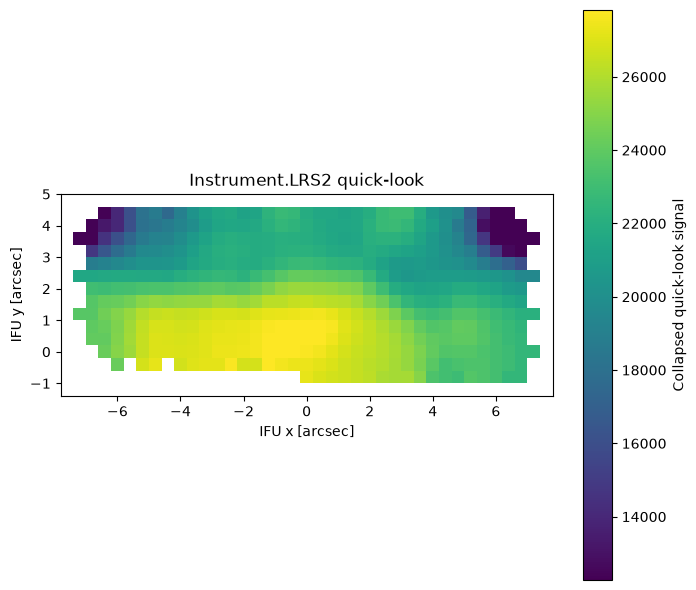

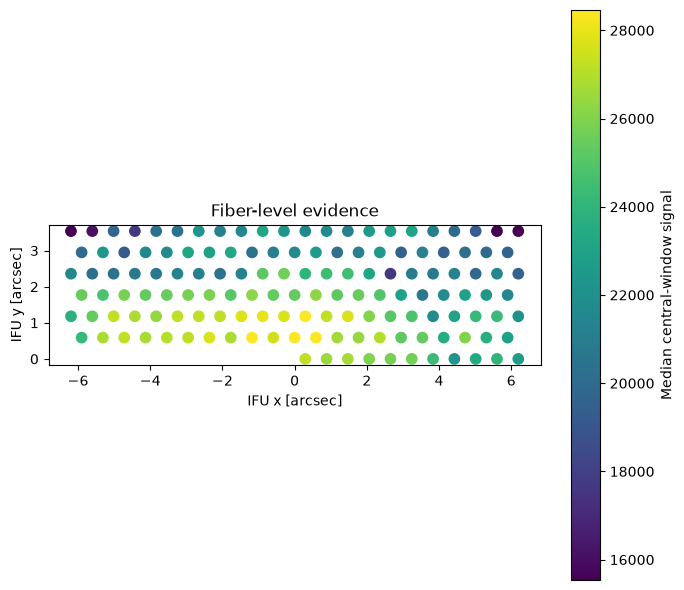

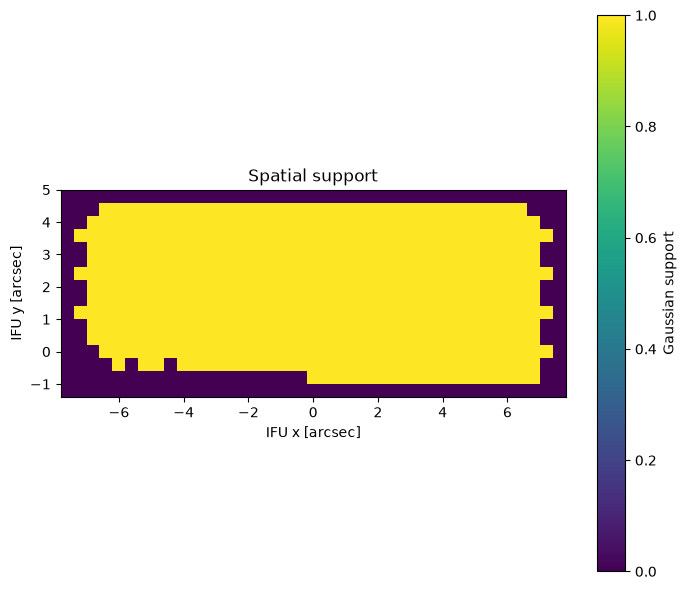

In [14]:
DISPLAY_PERCENTILES = (2.0, 98.0)

if "result" in globals():
    fig_spatial = plot_spatial_image(
        result,
        percentiles=DISPLAY_PERCENTILES,
        show_fibers=True,
        show_fiducial=(QUICKLOOK_KIND == "standard"),
        show_centroid=(QUICKLOOK_KIND == "standard"),
    )
    plt.show()

    fig_fibers = plot_fiber_values(
        result,
        percentiles=DISPLAY_PERCENTILES,
    )
    plt.show()

    fig_support = plot_spatial_support(result)
    plt.show()
else:
    print("Run a quick-look workflow first.")

## 11. Presentation experiments

This is where we should iterate together. Useful questions include:

- For flats, should the primary view emphasize absolute collapsed signal or relative fiber throughput?
- Should the fiber-center overlay always be visible, or only in a diagnostic view?
- Is a linear percentile stretch sufficient, or does a second normalized view reveal obstruction structure better?
- For standard stars, does the weighted centroid visually land where a human would put it?
- Which metadata belongs in the title versus a small evidence block?
- For VIRUS, do we want an IFU-detail product plus a separate whole-focal-plane overview?

Change **display choices here**, not the reduction algorithms.

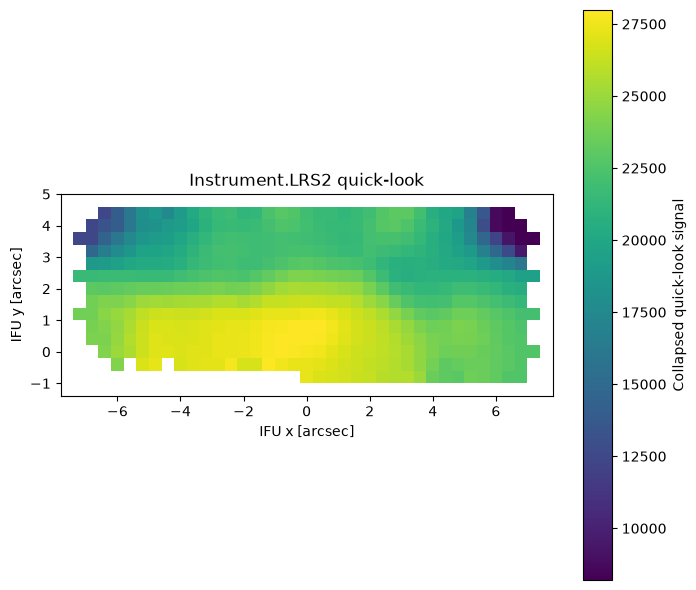

In [15]:
# Presentation knobs — intentionally separate from science defaults.
SHOW_FIBERS = True
SHOW_SUPPORT = False
DISPLAY_PERCENTILES = (1.0, 99.0)

if "result" in globals():
    fig = plot_spatial_image(
        result,
        percentiles=DISPLAY_PERCENTILES,
        show_fibers=SHOW_FIBERS,
        show_fiducial=(QUICKLOOK_KIND == "standard"),
        show_centroid=(QUICKLOOK_KIND == "standard"),
    )
    plt.show()

    if SHOW_SUPPORT:
        fig = plot_spatial_support(result)
        plt.show()

## 12. Save candidate presentation figures

Keep exported figures separate from the scientific result. This lets us iterate on presentation without changing numerical outputs.

In [16]:
OUTPUT_DIR = Path("notebook_output")
OUTPUT_DIR.mkdir(exist_ok=True)

def save_candidate(fig, name, *, dpi=160):
    path = OUTPUT_DIR / name
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(path.resolve())
    return path

# Example:
# save_candidate(fig_spatial, f"{DATE}_{INSTRUMENT}_{QUICKLOOK_KIND}_spatial.png")

# Next experiments

A useful sequence for the next interactive session:

1. Run one **LRS2 flat** and decide whether the spatial image + fiber samples make obstruction evidence obvious.
2. Run one **LRS2 standard** and judge the `(0,0)` versus measured position overlay.
3. Repeat on one **VIRUS IFU**.
4. Only after the single-IFU presentation is satisfactory, design the **whole-VIRUS focal-plane overview**.
5. Promote only presentation choices that prove useful on real data into `visualization.py`.

The notebook should stay exploratory. Once a plot becomes operationally convincing, move the smallest reusable plotting logic into the package and leave the experiment history here.